# India Job Market Analysis — Data Science & Data Analytics

**Objective:**  
Analyze job postings from Naukri.com to uncover what the Indian job market demands from Data Science and Data Analytics professionals.

**Dataset:** Naukri Data Scientist and Data Analytics Jobs  
**Total Records:** ~19,649 job postings  
**Columns:** Job Titles, Company Names, Experience Required, Package, Locations, Skills  

**Key Questions We'll Answer:**
-  Which cities have the most job openings?
-  What skills are most in demand?
-  What experience level do companies prefer?
-  Which companies are hiring the most?
-  How do Data Science vs Data Analytics roles differ in demand?

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print(' Libraries imported successfully!')

 Libraries imported successfully!


## Load Dataset

In [2]:
df = pd.read_csv('naukari_raw_data.csv')

print(f' Dataset loaded successfully!')
print(f' Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

 Dataset loaded successfully!
 Shape: 19,649 rows × 6 columns


,Job Titles,Company Names,Experience Required,Package,Locations,Skills
0,Manager - Digital Product Analytics [Data Scie...,Resy,4-8 Yrs,Not disclosed,Gurgaon/Gurugram,Product managementCareer developmentOperations...
1,Data Science Domain Manager,Coursera,7-11 Yrs,Not disclosed,"Kolkata, Mumbai, New Delhi, Hyderabad/Secunder...",Computer scienceContent strategyData analysisU...
2,GN - Strategy - MC - T&O - NLP Data Science - ...,Accenture,1-3 Yrs,Not disclosed,"Mumbai, Hyderabad/Secunderabad, Pune, Gurgaon/...",Change managementSASCodingData miningPythonRst...
3,Data Science Manager,Foreign IT Consulting MNC,2-6 Yrs,Not disclosed,Gurgaon/Gurugram,Operations researchSASFinanceProject managemen...
4,Data Science Manager,Foreign IT Consulting MNC,3-6 Yrs,Not disclosed,Noida,Data analysisEDCRisk assessmentrisk modelingMa...


## First Look at the Data

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19649 entries, 0 to 19648
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Job Titles           19522 non-null  object
 1   Company Names        19522 non-null  object
 2   Experience Required  19235 non-null  object
 3   Package              19522 non-null  object
 4   Locations            19589 non-null  object
 5   Skills               19466 non-null  object
dtypes: object(6)
memory usage: 921.2+ KB


# Missing values

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df)

                     Missing Count  Missing %
Job Titles                     127       0.65
Company Names                  127       0.65
Experience Required            414       2.11
Package                        127       0.65
Locations                       60       0.31
Skills                         183       0.93



# Drop rows where all key columns are null

In [5]:
df.dropna(subset=['Job Titles', 'Company Names','Experience Required', 'Skills', 'Locations'], inplace=True)
print(f' After dropping null Job/Company rows: {df.shape[0]:,} rows')

 After dropping null Job/Company rows: 19,229 rows


# Duplicate check

In [6]:
print(f' Duplicate rows: {df.duplicated().sum():,}')

 Duplicate rows: 0


# Drop duplicates

In [7]:
df.drop_duplicates(inplace=True)
print(f' After dropping duplicates: {df.shape[0]:,} rows')

 After dropping duplicates: 19,229 rows


# Reset index

In [8]:
df.reset_index(drop=True, inplace=True)
print(' Index reset done!')

 Index reset done!


#  Extract Role Type from Job Title 

In [9]:
def extract_role(title):
    title = str(title).lower()
    if 'data science' in title or 'data scientist' in title:
        return 'Data Science'
    elif 'analyst' in title or 'analytics' in title:
        return 'Data Analytics'
    else:
        return 'Other'


df['Role Type'] = df['Job Titles'].apply(extract_role)
print(' Role Type column created!')
print(df['Role Type'].value_counts())

 Role Type column created!
Role Type
Data Analytics    9810
Other             7149
Data Science      2270
Name: count, dtype: int64


# Clean Locations 

In [10]:
# Some cells have multiple cities separated by commas
# We'll take the FIRST city as primary locationabs


def clean_location(loc):
    if pd.isna(loc):
        return 'Unknown'
        
    city = str(loc).split(',')[0].strip()
    
    city = city.replace('Bangalore/Bengaluru', 'Bangalore')
    city = city.replace('Bengaluru', 'Bangalore')
    city = city.replace('Gurgaon/Gurugram', 'Gurgaon')
    city = city.replace('Gurugram', 'Gurgaon')
    city = city.replace('Hyderabad/Secunderabad', 'Hyderabad')
    city = city.replace('New Delhi', 'Delhi')
    return city

df['Primary Location'] = df['Locations'].apply(clean_location)
print(' Primary Location column created!')
print(df['Primary Location'].value_counts().head(10))

 Primary Location column created!
Primary Location
Bangalore    4165
Hyderabad    1942
Mumbai       1726
Gurgaon      1422
Pune         1322
Kolkata      1066
Remote       1020
Chennai       963
Noida         930
Delhi         698
Name: count, dtype: int64


#  Clean Experience 

In [11]:
# Format is like '4-8 Yrs', '0-1 Yrs', '10-15 Yrs'
# Extract min and max experience as integersabs

def extract_exp_min(exp):
    try:
        return int(str(exp).split('-')[0].strip())
    except:
        return np.nan

def extract_exp_max(exp):
    try:
        return int(str(exp).split('-')[1].replace('Yrs','').strip())
    except:
        return np.nan

def categorize_exp(min_exp):
    if pd.isna(min_exp):
        return 'Unknown'
    elif min_exp == 0:
        return 'Fresher (0 Yrs)'
    elif min_exp <= 2:
        return 'Junior (1-2 Yrs)'
    elif min_exp <= 5:
        return 'Mid Level (3-5 Yrs)'
    elif min_exp <= 10:
        return 'Senior (6-10 Yrs)'
    else:
        return 'Expert (10+ Yrs)'

df['Exp Min'] = df['Experience Required'].apply(extract_exp_min)
df['Exp Max'] = df['Experience Required'].apply(extract_exp_max)
df['Exp Category'] = df['Exp Min'].apply(categorize_exp)

print(' Experience columns created!')
print(df['Exp Category'].value_counts())

 Experience columns created!
Exp Category
Mid Level (3-5 Yrs)    8194
Junior (1-2 Yrs)       5991
Senior (6-10 Yrs)      3253
Fresher (0 Yrs)        1426
Expert (10+ Yrs)        365
Name: count, dtype: int64


#  Clean Package 

In [12]:
# Most values are 'Not disclosed' — we'll flag disclosed vs not 



df['Salary Disclosed'] = df['Package'].apply(
    lambda x: 'Disclosed' if str(x).lower() != 'not disclosed' and pd.notna(x) else 'Not Disclosed'
)

print(' Salary Disclosed column created!')
print(df['Salary Disclosed'].value_counts())

 Salary Disclosed column created!
Salary Disclosed
Not Disclosed    17511
Disclosed         1718
Name: count, dtype: int64


#  Final Cleaned Dataset Overview 


In [13]:
print(' Final Cleaned Dataset:')
print(f'Rows: {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')
print()
df.head()

 Final Cleaned Dataset:
Rows: 19,229
Columns: 12



,Job Titles,Company Names,Experience Required,Package,Locations,Skills,Role Type,Primary Location,Exp Min,Exp Max,Exp Category,Salary Disclosed
0,Manager - Digital Product Analytics [Data Scie...,Resy,4-8 Yrs,Not disclosed,Gurgaon/Gurugram,Product managementCareer developmentOperations...,Data Science,Gurgaon,4,8,Mid Level (3-5 Yrs),Not Disclosed
1,Data Science Domain Manager,Coursera,7-11 Yrs,Not disclosed,"Kolkata, Mumbai, New Delhi, Hyderabad/Secunder...",Computer scienceContent strategyData analysisU...,Data Science,Kolkata,7,11,Senior (6-10 Yrs),Not Disclosed
2,GN - Strategy - MC - T&O - NLP Data Science - ...,Accenture,1-3 Yrs,Not disclosed,"Mumbai, Hyderabad/Secunderabad, Pune, Gurgaon/...",Change managementSASCodingData miningPythonRst...,Data Science,Mumbai,1,3,Junior (1-2 Yrs),Not Disclosed
3,Data Science Manager,Foreign IT Consulting MNC,2-6 Yrs,Not disclosed,Gurgaon/Gurugram,Operations researchSASFinanceProject managemen...,Data Science,Gurgaon,2,6,Junior (1-2 Yrs),Not Disclosed
4,Data Science Manager,Foreign IT Consulting MNC,3-6 Yrs,Not disclosed,Noida,Data analysisEDCRisk assessmentrisk modelingMa...,Data Science,Noida,3,6,Mid Level (3-5 Yrs),Not Disclosed


# Save cleaned dataset

In [14]:
df.to_csv('cleaned_jobs.csv', index=False)
print('Cleaned dataset saved as cleaned_jobs.csv!')

Cleaned dataset saved as cleaned_jobs.csv!


## Preprocessing for Skills Analysis

In [15]:
# The Skills column has all skills mashed together without separators.
# We'll use a smart split approach to extract individual skills.
# Common separators found: no separator (camelCase), commas, etc.
# We'll use a known skills dictionary approach to extract top skills.

# Define a comprehensive list of known data skills to search for
known_skills = [
    'Python', 'SQL', 'R', 'Excel', 'Tableau', 'Power BI', 'PowerBI',
    'Machine Learning', 'Deep Learning', 'NLP', 'Statistics',
    'Data Analysis', 'Data Science', 'Data Mining', 'Data Visualization',
    'TensorFlow', 'Keras', 'PyTorch', 'Scikit', 'Pandas', 'NumPy',
    'Spark', 'Hadoop', 'Big Data', 'AWS', 'Azure', 'GCP', 'Cloud',
    'MongoDB', 'MySQL', 'PostgreSQL', 'NoSQL',
    'Computer Vision', 'Feature Engineering', 'A/B Testing',
    'Business Intelligence', 'ETL', 'Airflow', 'Docker', 'Git',
    'Communication', 'Problem Solving', 'Analytical', 'Leadership',
    'SAS', 'SPSS', 'Regression', 'Classification', 'Clustering'
]

skill_counts = {}

for skill in known_skills:
    count = df['Skills'].dropna().str.contains(skill, case=False).sum()
    skill_counts[skill] = count

skills_df = pd.DataFrame(list(skill_counts.items()), columns=['Skill', 'Count'])
skills_df = skills_df.sort_values('Count', ascending=False).reset_index(drop=True)

print(' Skills extracted!')
print(skills_df.head(15))



 Skills extracted!
                    Skill  Count
0                       R  18551
1           Data Analysis   4840
2              Analytical   4380
3                     SQL   3580
4        Machine Learning   2681
5                  Python   1614
6                   Excel   1601
7            Data Science   1444
8   Business Intelligence   1149
9                Power BI   1027
10            Data Mining    963
11     Data Visualization    870
12                    SAS    812
13                  Cloud    780
14                    Git    769


## Save skills summary separately 


In [16]:
skills_df.to_csv('skills_summary.csv', index=False)
print(f' skills_summary.csv saved!')
print(f' Total skills tracked: {len(skills_df)}')

 skills_summary.csv saved!
 Total skills tracked: 49


#  Exploratory Data Analysis (EDA)

## Role Type Distribution (DS vs DA)

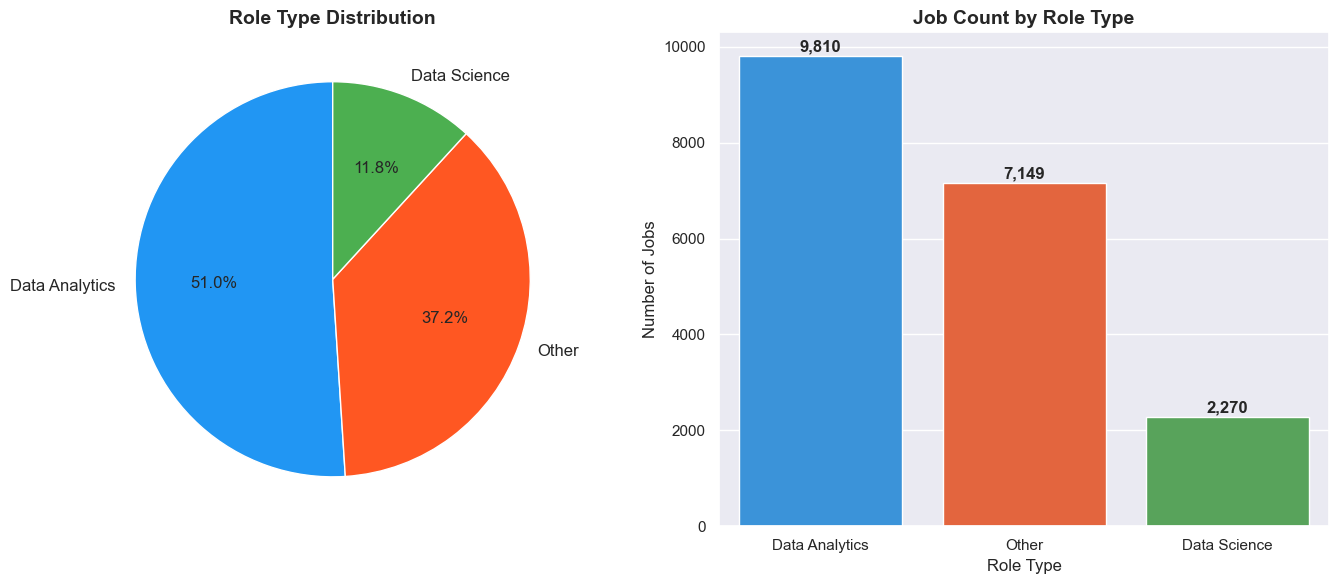

 Saved: plot_01_role_distribution.png


In [17]:
role_counts = df['Role Type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))


colors = ['#2196F3', '#FF5722', '#4CAF50']
axes[0].pie(role_counts, labels=role_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 12})
axes[0].set_title('Role Type Distribution', fontsize=14, fontweight='bold')


sns.barplot(x=role_counts.index, y=role_counts.values, palette=colors, ax=axes[1])
axes[1].set_title('Job Count by Role Type', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Role Type')
axes[1].set_ylabel('Number of Jobs')
for i, v in enumerate(role_counts.values):
    axes[1].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('plot_01_role_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: plot_01_role_distribution.png')

## Top 15 Cities by Job Openings

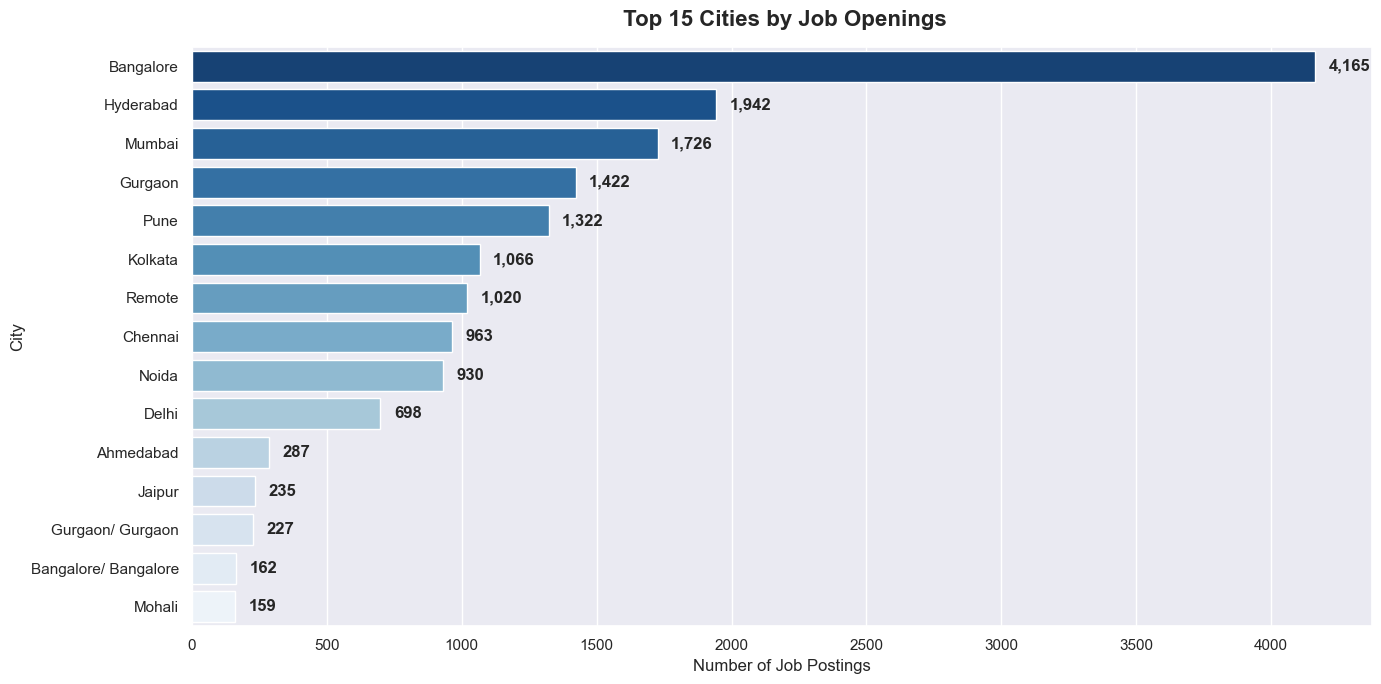

 Saved: plot_02_top_cities.png


In [18]:
top_cities = df['Primary Location'].value_counts().head(15)

plt.figure(figsize=(14, 7))
bars = sns.barplot(x=top_cities.values, y=top_cities.index,
                   palette='Blues_r')

for i, v in enumerate(top_cities.values):
    plt.text(v + 50, i, f'{v:,}', va='center', fontweight='bold')

plt.title(' Top 15 Cities by Job Openings', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Number of Job Postings')
plt.ylabel('City')
plt.tight_layout()
plt.savefig('plot_02_top_cities.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: plot_02_top_cities.png')

## Top 20 Most In-Demand Skills

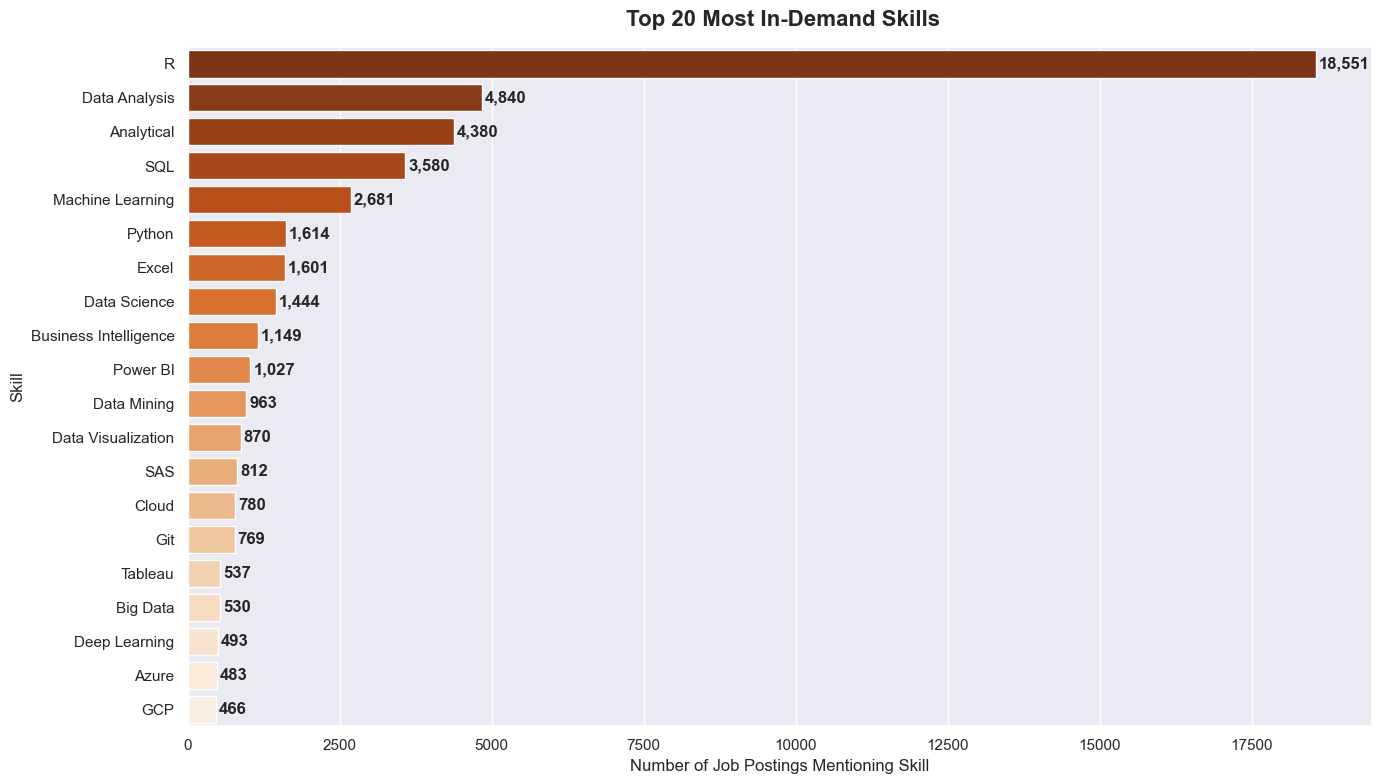

 Saved: plot_03_top_skills.png


In [19]:
top_skills = skills_df.head(20)

plt.figure(figsize=(14, 8))
sns.barplot(x='Count', y='Skill', data=top_skills, palette='Oranges_r')

for i, row in enumerate(top_skills.itertuples()):
    plt.text(row.Count + 50, i, f'{row.Count:,}', va='center', fontweight='bold')

plt.title(' Top 20 Most In-Demand Skills', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Number of Job Postings Mentioning Skill')
plt.ylabel('Skill')
plt.tight_layout()
plt.savefig('plot_03_top_skills.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: plot_03_top_skills.png')

## Experience Level Distribution

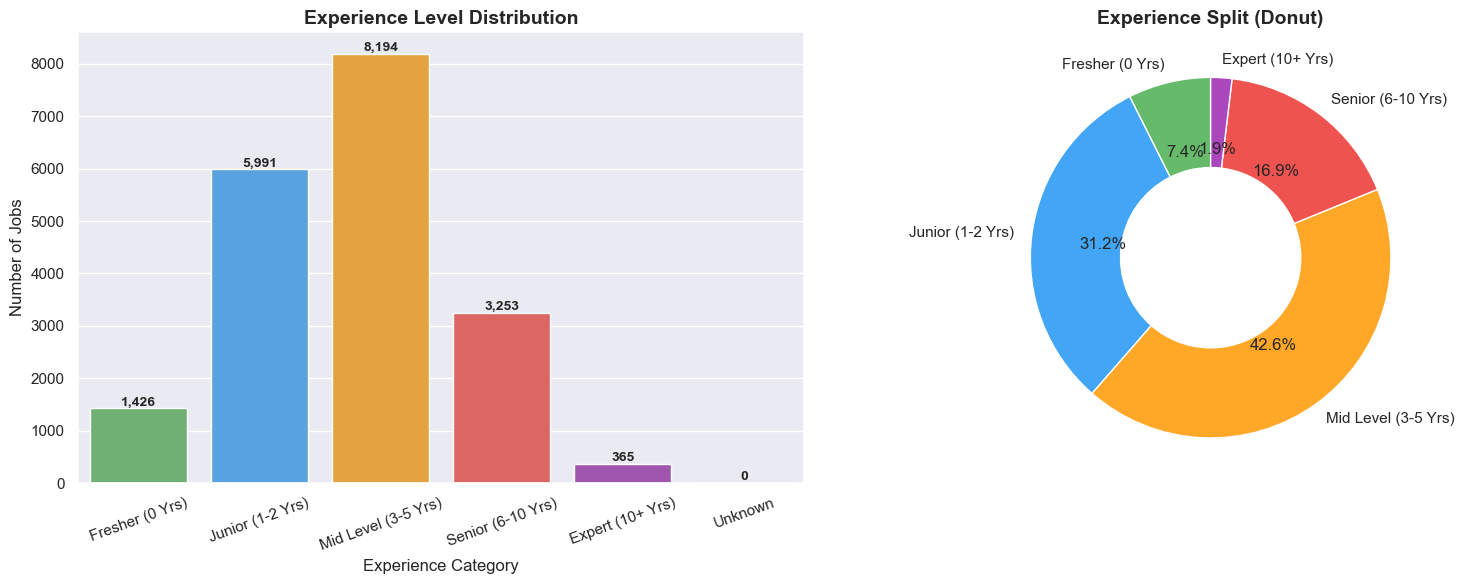

 Saved: plot_04_experience.png


In [20]:
exp_order = ['Fresher (0 Yrs)', 'Junior (1-2 Yrs)', 'Mid Level (3-5 Yrs)',
             'Senior (6-10 Yrs)', 'Expert (10+ Yrs)', 'Unknown']

exp_counts = df['Exp Category'].value_counts().reindex(exp_order).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
colors_exp = ['#66BB6A', '#42A5F5', '#FFA726', '#EF5350', '#AB47BC', '#78909C']
sns.barplot(x=exp_counts.index, y=exp_counts.values,
            palette=colors_exp, ax=axes[0])
axes[0].set_title('Experience Level Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Experience Category')
axes[0].set_ylabel('Number of Jobs')
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(exp_counts.values):
    axes[0].text(i, v + 50, f'{int(v):,}', ha='center', fontweight='bold', fontsize=10)

# Donut chart
filtered = exp_counts[exp_counts > 0]
wedges, texts, autotexts = axes[1].pie(
    filtered, labels=filtered.index, autopct='%1.1f%%',
    colors=colors_exp[:len(filtered)], startangle=90,
    wedgeprops=dict(width=0.5)
)
axes[1].set_title('Experience Split (Donut)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('plot_04_experience.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: plot_04_experience.png')

 ## Top 15 Hiring Companies

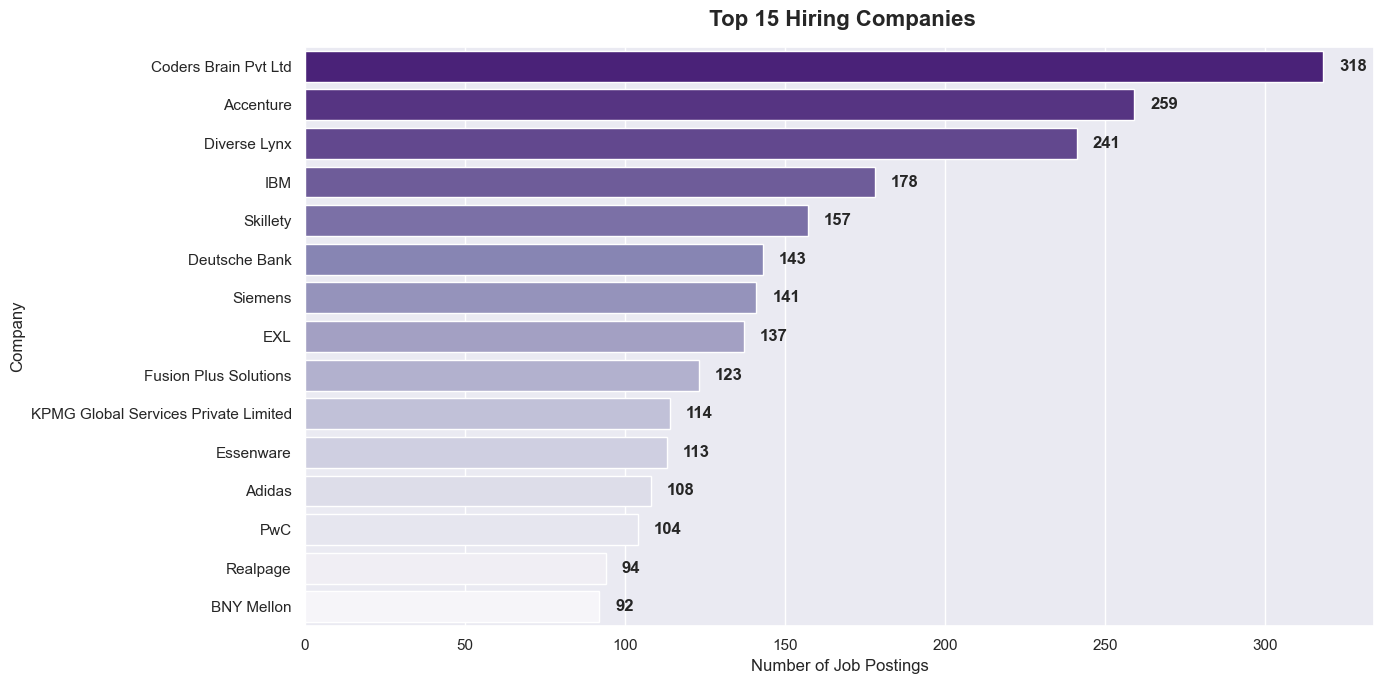

 Saved: plot_05_top_companies.png


In [21]:
top_companies = df['Company Names'].value_counts().head(15)

plt.figure(figsize=(14, 7))
sns.barplot(x=top_companies.values, y=top_companies.index, palette='Purples_r')

for i, v in enumerate(top_companies.values):
    plt.text(v + 5, i, f'{v:,}', va='center', fontweight='bold')

plt.title(' Top 15 Hiring Companies', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Number of Job Postings')
plt.ylabel('Company')
plt.tight_layout()
plt.savefig('plot_05_top_companies.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: plot_05_top_companies.png')

 ## DS vs DA: Skills Comparison

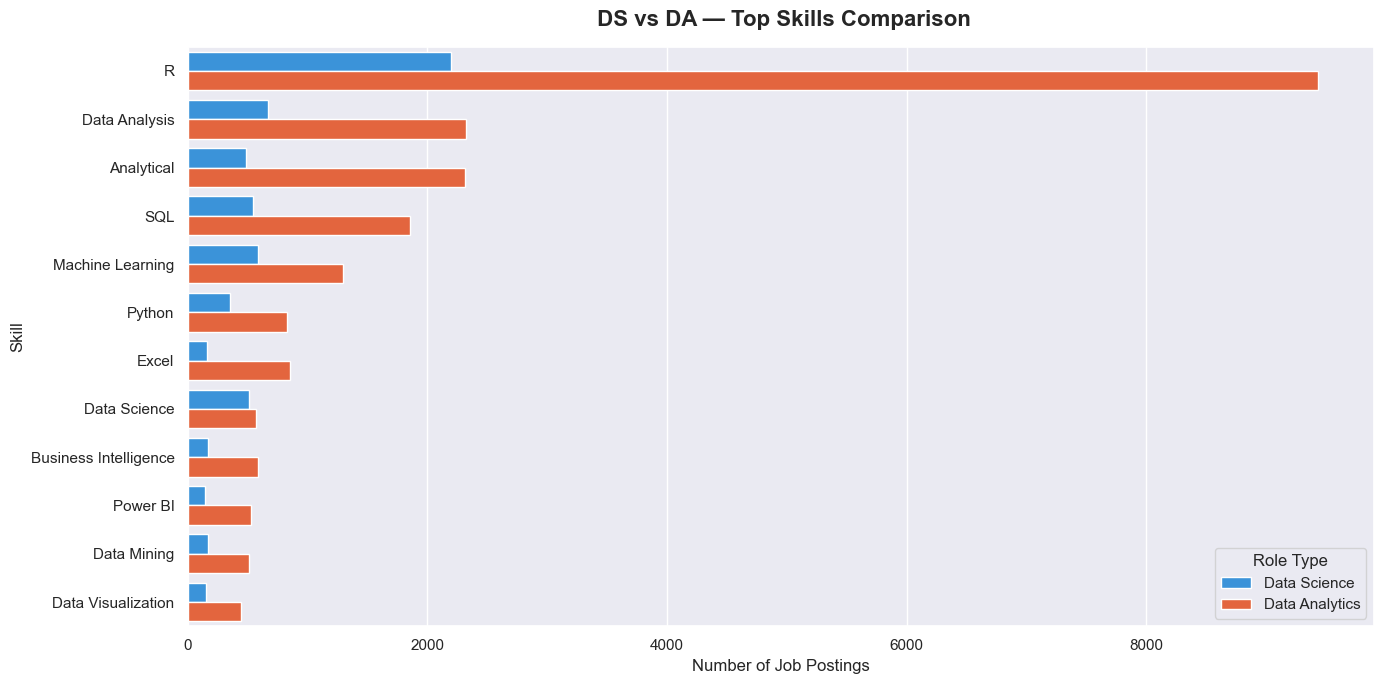

 Saved: plot_06_ds_vs_da_skills.png


In [22]:
# Filter only DS and DA roles
ds_df = df[df['Role Type'] == 'Data Science']
da_df = df[df['Role Type'] == 'Data Analytics']

# Top skills for each role
top_skills_list = skills_df.head(12)['Skill'].tolist()

ds_skill_counts = []
da_skill_counts = []

for skill in top_skills_list:
    ds_skill_counts.append(ds_df['Skills'].dropna().str.contains(skill, case=False).sum())
    da_skill_counts.append(da_df['Skills'].dropna().str.contains(skill, case=False).sum())

comparison_df = pd.DataFrame({
    'Skill': top_skills_list,
    'Data Science': ds_skill_counts,
    'Data Analytics': da_skill_counts
})

comparison_melted = comparison_df.melt(id_vars='Skill', var_name='Role', value_name='Count')

plt.figure(figsize=(14, 7))
sns.barplot(data=comparison_melted, x='Count', y='Skill',
            hue='Role', palette=['#2196F3', '#FF5722'])

plt.title(' DS vs DA — Top Skills Comparison', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Number of Job Postings')
plt.ylabel('Skill')
plt.legend(title='Role Type')
plt.tight_layout()
plt.savefig('plot_06_ds_vs_da_skills.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: plot_06_ds_vs_da_skills.png')

## Experience Distribution by Role Type

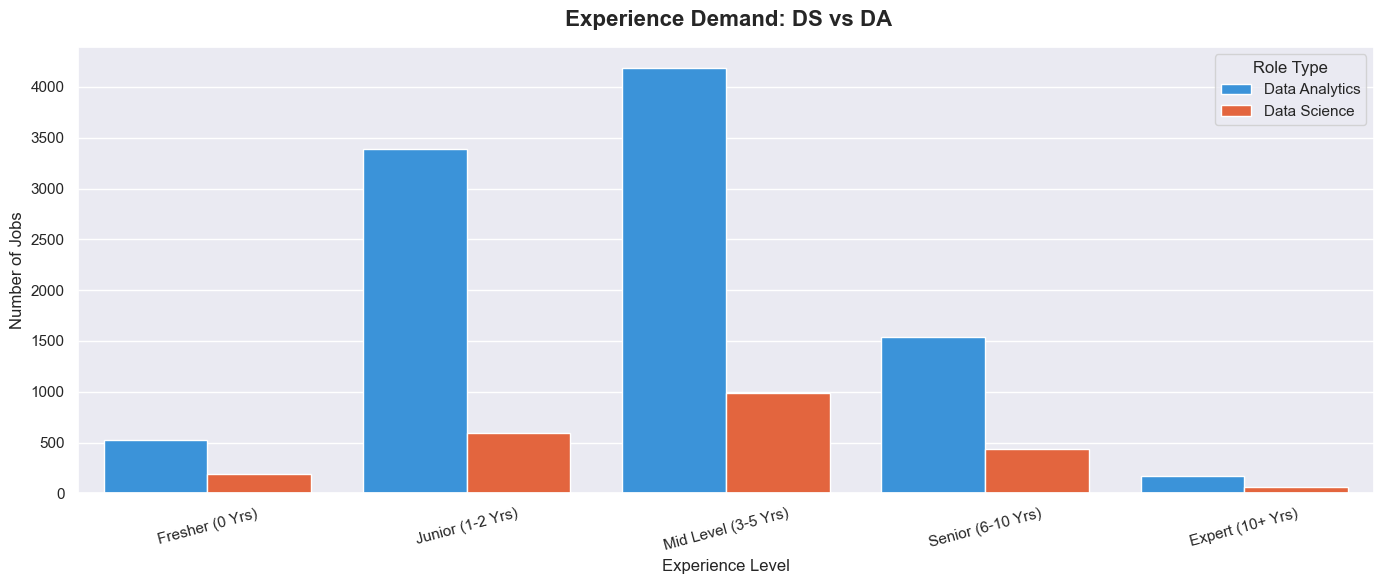

 Saved: plot_07_exp_by_role.png


In [23]:
exp_role = df[df['Role Type'].isin(['Data Science', 'Data Analytics'])]\
             .groupby(['Role Type', 'Exp Category']).size().reset_index(name='Count')

plt.figure(figsize=(14, 6))
sns.barplot(data=exp_role, x='Exp Category', y='Count',
            hue='Role Type', palette=['#2196F3', '#FF5722'],
            order=exp_order[:-1])

plt.title(' Experience Demand: DS vs DA', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Experience Level')
plt.ylabel('Number of Jobs')
plt.xticks(rotation=15)
plt.legend(title='Role Type')
plt.tight_layout()
plt.savefig('plot_07_exp_by_role.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: plot_07_exp_by_role.png')

## Top Cities per Role Type

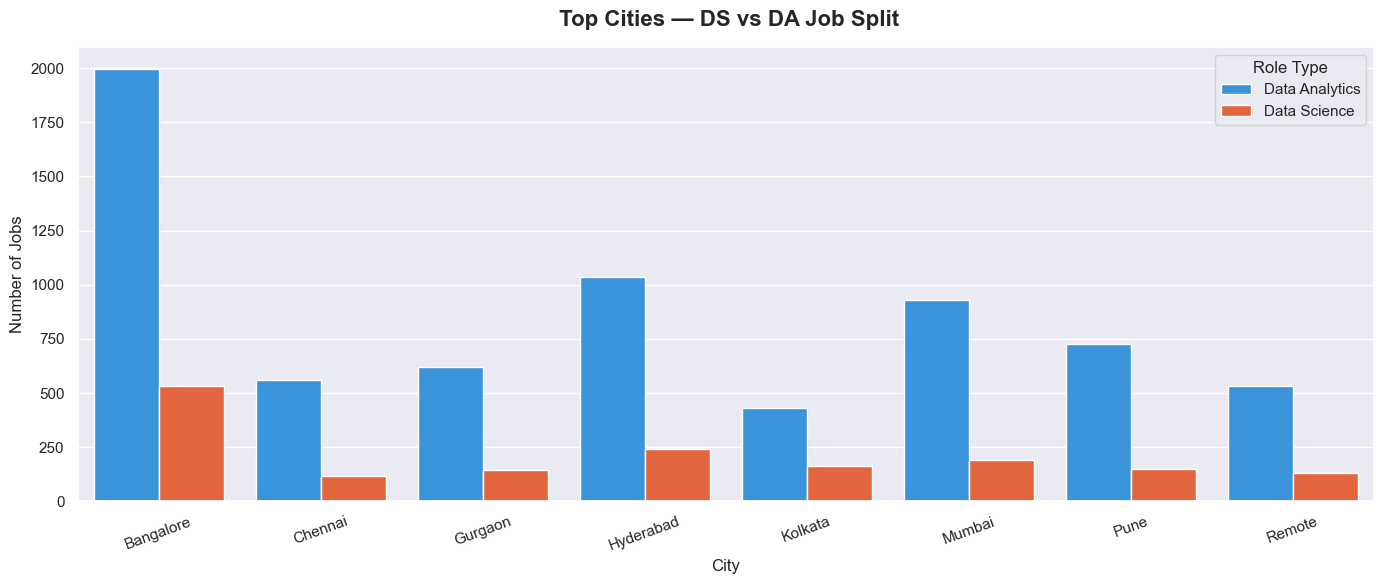

 Saved: plot_08_cities_by_role.png


In [24]:
top_cities_list = df['Primary Location'].value_counts().head(8).index.tolist()

city_role = df[
    (df['Role Type'].isin(['Data Science', 'Data Analytics'])) &
    (df['Primary Location'].isin(top_cities_list))
].groupby(['Primary Location', 'Role Type']).size().reset_index(name='Count')

plt.figure(figsize=(14, 6))
sns.barplot(data=city_role, x='Primary Location', y='Count',
            hue='Role Type', palette=['#2196F3', '#FF5722'])

plt.title(' Top Cities — DS vs DA Job Split', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('City')
plt.ylabel('Number of Jobs')
plt.xticks(rotation=20)
plt.legend(title='Role Type')
plt.tight_layout()
plt.savefig('plot_08_cities_by_role.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: plot_08_cities_by_role.png')

## Key Insights Summary

In [25]:
print('=' * 60)
print(' KEY INSIGHTS — INDIA JOB MARKET ANALYSIS')
print('=' * 60)

print(f'\n Total Job Postings Analyzed: {df.shape[0]:,}')

print(f'\n Role Split:')
for role, count in df['Role Type'].value_counts().items():
    print(f'   {role}: {count:,} ({count/len(df)*100:.1f}%)')

print(f'\n Top 5 Hiring Cities:')
for city, count in df['Primary Location'].value_counts().head(5).items():
    print(f'   {city}: {count:,} jobs')

print(f'\n Top 5 Most In-Demand Skills:')
for _, row in skills_df.head(5).iterrows():
    print(f'   {row["Skill"]}: {row["Count"]:,} mentions')

print(f'\n Experience Demand:')
for exp, count in df['Exp Category'].value_counts().items():
    print(f'   {exp}: {count:,} ({count/len(df)*100:.1f}%)')

print(f'\n Top 5 Hiring Companies:')
for company, count in df['Company Names'].value_counts().head(5).items():
    print(f'   {company}: {count:,} jobs')

print('\n' + '=' * 20)
print(' Analysis Complete!' )
print('=' * 20)

 KEY INSIGHTS — INDIA JOB MARKET ANALYSIS

 Total Job Postings Analyzed: 19,229

 Role Split:
   Data Analytics: 9,810 (51.0%)
   Other: 7,149 (37.2%)
   Data Science: 2,270 (11.8%)

 Top 5 Hiring Cities:
   Bangalore: 4,165 jobs
   Hyderabad: 1,942 jobs
   Mumbai: 1,726 jobs
   Gurgaon: 1,422 jobs
   Pune: 1,322 jobs

 Top 5 Most In-Demand Skills:
   R: 18,551 mentions
   Data Analysis: 4,840 mentions
   Analytical: 4,380 mentions
   SQL: 3,580 mentions
   Machine Learning: 2,681 mentions

 Experience Demand:
   Mid Level (3-5 Yrs): 8,194 (42.6%)
   Junior (1-2 Yrs): 5,991 (31.2%)
   Senior (6-10 Yrs): 3,253 (16.9%)
   Fresher (0 Yrs): 1,426 (7.4%)
   Expert (10+ Yrs): 365 (1.9%)

 Top 5 Hiring Companies:
   Coders Brain Pvt Ltd: 318 jobs
   Accenture: 259 jobs
   Diverse Lynx: 241 jobs
   IBM: 178 jobs
   Skillety: 157 jobs

 Analysis Complete!


## Connect to PostgreSQL

In [27]:
from sqlalchemy import create_engine


username = "postgres"    
password = "akansha1622k" 
host = "localhost"        
port = "5432"              
database = "Job_market_db"   

engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")


table_name = "jobs"  
df.to_sql(table_name, engine, if_exists="replace", index=False)

print(f"Data successfully loaded into table '{table_name}' in database '{database}'.")

Data successfully loaded into table 'jobs' in database 'Job_market_db'.
